In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow

Loading data from disk...
Encoding labels...
Training samples: 9584 | Validation samples: 2396


Model: "Graph_Siamese_Network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Video_A             │ (None, 100, 75,   │          0 │ -                 │
│ (InputLayer)        │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Video_B             │ (None, 100, 75,   │          0 │ -                 │
│ (InputLayer)        │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Graph_Encoder       │ (None, 128)       │  1,144,192 │ Video_A[0][0],    │
│ (Functional)        │                   │            │ Video_B[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 128)       │          0 │ Graph_Encoder[0]… │
│                     │                   │            │ Graph_Encoder[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 128)       │          0 │ Graph_Encoder[0]… │
│ (Multiply)          │                   │            │ Graph_Encoder[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 256)       │          0 │ lambda_11[0][0],  │
│ (Concatenate)       │                   │            │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 128)       │     32,896 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_49          │ (None, 128)       │          0 │ dense_76[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_77 (Dense)    │ (None, 1)         │        129 │ dropout_49[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,177,217 (4.49 MB)

 Trainable params: 1,177,089 (4.49 MB)

 Non-trainable params: 128 (512.00 B)


🚀 Starting Graph-Siamese Training...

Epoch 1/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6060 - loss: 0.6870
Epoch 1: val_accuracy improved from None to 0.75576, saving model to /content/drive/MyDrive/535 Project/best_graph_siamese_simease2000.keras

Epoch 1: finished saving model to /content/drive/MyDrive/535 Project/best_graph_siamese_simease2000.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 37s 189ms/step - accuracy: 0.6572 - loss: 0.6623 - val_accuracy: 0.7558 - val_loss: 0.5897 - learning_rate: 1.0000e-04
Epoch 2/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7527 - loss: 0.5928
Epoch 2: val_accuracy improved from 0.75576 to 0.83470, saving model to /content/drive/MyDrive/535 Project/best_graph_siamese_simease2000.keras

Epoch 2: finished saving model to /content/drive/MyDrive/535 Project/best_graph_siamese_simease2000.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 27s 178ms/step - accuracy: 0.7713 - loss: 0.5694 - val_accuracy: 0.8347 - val_loss: 0.4921 - learning_rate:

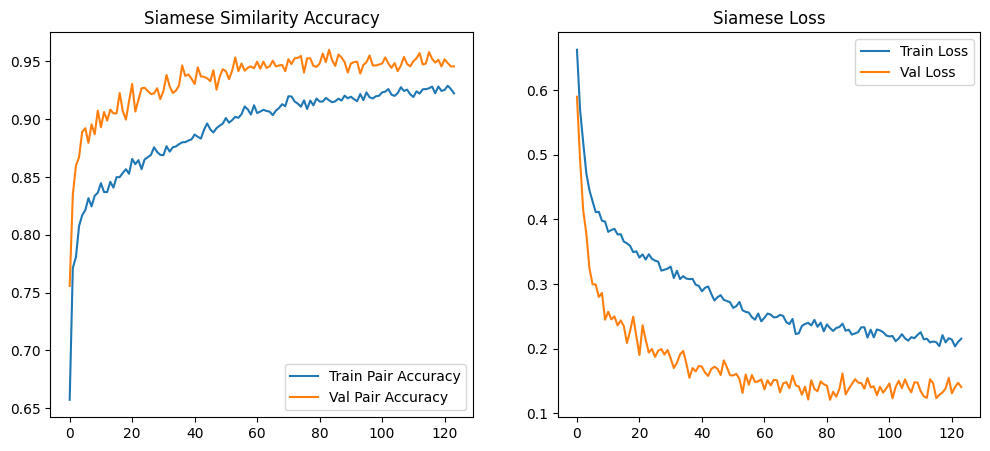

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import PyDataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import LabelEncoder

BASE_DIR = "/content/drive/MyDrive/535 Project/"
MODEL_FILE = BASE_DIR + "best_graph_simease2000.keras"
ENCODER_FILE = BASE_DIR + "wlasl_label_encoder_simease2000.pkl"
PLOT_FILE = BASE_DIR + "siamese_training_plot.png"


MAX_FRAMES = 100
BATCH_SIZE = 64

# ==========================================
# 1. LOAD & ENCODE
# ==========================================
print("Loading data from disk...")
X_raw = np.load(BASE_DIR + "X_data_standardized.npy", allow_pickle=True)
y_raw = np.load(BASE_DIR + "y_labels.npy", allow_pickle=True)

print("Encoding labels...")
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)
joblib.dump(le, ENCODER_FILE)

X_train, X_val, y_train, y_val = train_test_split(
    X_raw, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

# ==========================================
# 2. SIAMESE DATA GENERATOR
# ==========================================
class SiameseKinematicGenerator(PyDataset):
    def __init__(self, X_data, y_data, batch_size=32, max_frames=100, is_training=False, **kwargs):
        super().__init__(**kwargs)
        self.X = X_data
        self.y = y_data
        self.batch_size = batch_size
        self.max_frames = max_frames
        self.is_training = is_training

        # Group indices by class so we can easily pair them up
        self.classes = np.unique(self.y)
        self.class_indices = {cls: np.where(self.y == cls)[0] for cls in self.classes}

    def normalize_skeleton(self, seq_3d):
        center = seq_3d[:, 11:12, :]
        seq_3d = seq_3d - center
        shoulder_dist = np.linalg.norm(seq_3d[:, 11] - seq_3d[:, 12], axis=-1)
        scale = np.mean(shoulder_dist) + 1e-6
        return seq_3d / scale

    def augment(self, seq_3d):
        frames, joints, coords = seq_3d.shape
        noise = np.random.normal(0, 0.01, seq_3d.shape)
        seq_3d = seq_3d + noise

        if np.random.rand() < 0.8:
            scale_factor = np.random.uniform(0.9, 1.1)
            seq_3d[:, :, :3] *= scale_factor

        if np.random.rand() < 0.3:
            drop_ratio = 0.08
            drop_idx = np.random.choice(frames, int(frames * drop_ratio), replace=False)
            seq_3d[drop_idx] = 0

        if np.random.rand() < 0.2:
            keep_idx = np.sort(np.random.choice(frames, int(frames * 0.9), replace=False))
            seq_3d = seq_3d[keep_idx]
            if seq_3d.shape[0] < frames:
                pad = np.zeros((frames - seq_3d.shape[0], joints, coords))
                seq_3d = np.concatenate([seq_3d, pad], axis=0)

        return seq_3d

    def process_seq(self, seq_3d):
        frames_count = seq_3d.shape[0]
        seq_3d = seq_3d.reshape((frames_count, 75, 3))
        seq_3d = self.normalize_skeleton(seq_3d)

        if self.is_training:
            seq_3d = self.augment(seq_3d)

        frames_count = seq_3d.shape[0]
        vel = np.zeros_like(seq_3d)
        vel[1:] = seq_3d[1:] - seq_3d[:-1]

        acc = np.zeros_like(seq_3d)
        acc[1:] = vel[1:] - vel[:-1]

        kinematic_seq = np.concatenate([seq_3d, vel, acc], axis=-1)

        if frames_count >= self.max_frames:
            kinematic_seq = kinematic_seq[:self.max_frames]
        else:
            pad_width = self.max_frames - frames_count
            kinematic_seq = np.pad(kinematic_seq, ((0, pad_width), (0, 0), (0, 0)), mode='constant', constant_values=0.0)

        return kinematic_seq

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        batch_x1, batch_x2, batch_y = [], [], []
        half_batch = self.batch_size // 2

        # 1. Generate Positive Pairs (Same Sign -> Label 1)
        for _ in range(half_batch):
            target_class = np.random.choice(self.classes)
            idx1, idx2 = np.random.choice(self.class_indices[target_class], 2, replace=True)
            batch_x1.append(self.process_seq(self.X[idx1]))
            batch_x2.append(self.process_seq(self.X[idx2]))
            batch_y.append(1.0)

        # 2. Generate Negative Pairs (Different Signs -> Label 0)
        for _ in range(self.batch_size - half_batch):
            cls1, cls2 = np.random.choice(self.classes, 2, replace=False)
            idx1 = np.random.choice(self.class_indices[cls1])
            idx2 = np.random.choice(self.class_indices[cls2])
            batch_x1.append(self.process_seq(self.X[idx1]))
            batch_x2.append(self.process_seq(self.X[idx2]))
            batch_y.append(0.0)

        return {"Video_A": np.array(batch_x1, dtype=np.float32),
            "Video_B": np.array(batch_x2, dtype=np.float32)
        }, np.array(batch_y, dtype=np.float32)


train_gen = SiameseKinematicGenerator(X_train, y_train, batch_size=BATCH_SIZE, max_frames=MAX_FRAMES, is_training=True)
val_gen = SiameseKinematicGenerator(X_val, y_val, batch_size=BATCH_SIZE, max_frames=MAX_FRAMES, is_training=False)

# ==========================================
# 3. ARCHITECTURE (Graph-Jamba Blocks)
# ==========================================
def build_adjacency_matrix():
    NUM_JOINTS = 75
    A = np.zeros((NUM_JOINTS, NUM_JOINTS), dtype=np.float32)

    pose_edges = [
        (0,1), (1,2), (2,3), (3,7), (0,4), (4,5), (5,6), (6,8), (9,10),
        (11,12), (11,13), (13,15), (15,17), (15,19), (15,21), (17,19),
        (12,14), (14,16), (16,18), (16,20), (16,22), (18,20),
        (11,23), (12,24), (23,24),
        (23,25), (25,27), (27,29), (27,31), (29,31),
        (24,26), (26,28), (28,30), (28,32), (30,32)
    ]
    hand_edges = [
        (0,1), (1,2), (2,3), (3,4),
        (0,5), (5,6), (6,7), (7,8),
        (5,9), (9,10), (10,11), (11,12),
        (9,13), (13,14), (14,15), (15,16),
        (13,17), (0,17), (17,18), (18,19), (19,20)
    ]
    edges = []
    edges.extend(pose_edges)
    for u, v in hand_edges: edges.append((u + 33, v + 33))
    for u, v in hand_edges: edges.append((u + 54, v + 54))
    edges.append((15, 33))
    edges.append((16, 54))

    for u, v in edges:
        A[u, v] = 1.0
        A[v, u] = 1.0

    I = np.eye(NUM_JOINTS)
    A = A + I
    D = np.sum(A, axis=1)
    D_inv_sqrt = np.power(D, -0.5)
    D_inv_sqrt[np.isinf(D_inv_sqrt)] = 0.0
    D_mat = np.diag(D_inv_sqrt)
    A_normalized = np.dot(D_mat, np.dot(A, D_mat))
    return tf.constant(A_normalized, dtype=tf.float32)

class SpatialGraphConv(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.A = build_adjacency_matrix()
        self.dense = layers.Dense(units, activation='relu')

    def call(self, inputs):
        h = self.dense(inputs)
        return tf.einsum('vw, btwc -> btvc', self.A, h)

class MambaStyleBlock(layers.Layer):
    def __init__(self, d_model, kernel_size=4, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.norm = layers.LayerNormalization()
        self.conv1d = layers.Conv1D(filters=d_model, kernel_size=kernel_size, padding='causal', activation='silu')
        self.ssm_scan = layers.GRU(d_model, return_sequences=True)
        self.out_proj = layers.Dense(d_model)

    def call(self, inputs):
        x = self.norm(inputs)
        x_conv = self.conv1d(x)
        x_ssm = self.ssm_scan(x_conv)
        out = self.out_proj(x_ssm)
        return inputs + out

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim)])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


# ==========================================
# 4. BUILD THE GRAPH SIAMESE NETWORK
# ==========================================
def build_graph_encoder(max_frames, num_joints, features):
    inputs = keras.Input(shape=(max_frames, num_joints, features))

    x = SpatialGraphConv(units=64)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Reshape((max_frames, -1))(x)

    x = layers.Dense(128, activation='relu')(x)

    x = MambaStyleBlock(d_model=128)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = TransformerBlock(embed_dim=128, num_heads=4, ff_dim=256, rate=0.2)(x)
    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)

    # 🚨 CRITICAL for Siamese: L2 Normalize the output embedding so distances map cleanly!
    outputs = layers.UnitNormalization(axis=1)(x)

    return keras.Model(inputs, outputs, name="Graph_Encoder")

# Instantiate ONE encoder to act as the "Twin"
encoder = build_graph_encoder(max_frames=MAX_FRAMES, num_joints=75, features=9)

# Create two inputs (Video A and Video B)
input_a = layers.Input(shape=(MAX_FRAMES, 75, 9), name="Video_A")
input_b = layers.Input(shape=(MAX_FRAMES, 75, 9), name="Video_B")

# Pass both videos through the SAME Graph-Jamba brain
emb_a = encoder(input_a)
emb_b = encoder(input_b)

# Compare the embeddings
diff = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([emb_a, emb_b])
mul = layers.Multiply()([emb_a, emb_b])
merged = layers.Concatenate()([diff, mul])

x = layers.Dense(128, activation="relu")(merged)
x = layers.Dropout(0.4)(x)

# 🚨 Output is Binary: 1 = Match, 0 = Different!
output = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=[input_a, input_b], outputs=output, name="Graph_Siamese_Network")

# ==========================================
# 5. COMPILE AND TRAIN
# ==========================================
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss='binary_crossentropy', # Changed to Binary since we are checking Match vs No-Match
    metrics=['accuracy']
)

model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=40, restore_best_weights=True, verbose=1)
checkpoint = keras.callbacks.ModelCheckpoint(filepath=MODEL_FILE, monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=15, verbose=1)

print("\n🚀 Starting Graph-Siamese Training...\n")
history = model.fit(
    train_gen,
    epochs=200,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 6. PLOT
# ==========================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Pair Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Pair Accuracy')
plt.title('Siamese Similarity Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Siamese Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=300)
print(f"✅ Training plot saved to: {PLOT_FILE}")
plt.show()

In [ ]:
import numpy as np
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ==========================================
# PATHS
# ==========================================
BASE_DIR = "/content/drive/MyDrive/535 Project/"
X_FILE = BASE_DIR + "X_data_standardized.npy"
Y_FILE = BASE_DIR + "y_labels.npy"
MODEL_FILE = BASE_DIR + "best_graph_simease2000.keras"
OUTPUT_FILE = BASE_DIR + "asl_reference_library.json"

MAX_FRAMES = 100

# ==========================================
# CUSTOM LAYERS (MUST MATCH TRAINING EXACTLY)
# ==========================================

def build_adjacency_matrix():
    NUM_JOINTS = 75
    A = np.zeros((NUM_JOINTS, NUM_JOINTS), dtype=np.float32)

    pose_edges = [
        (0,1), (1,2), (2,3), (3,7), (0,4), (4,5), (5,6), (6,8),
        (9,10), (11,12), (11,13), (13,15), (15,17), (15,19),
        (15,21), (17,19), (12,14), (14,16), (16,18), (16,20),
        (16,22), (18,20), (11,23), (12,24), (23,24)
    ]

    hand_edges = [
        (0,1),(1,2),(2,3),(3,4),
        (0,5),(5,6),(6,7),(7,8),
        (5,9),(9,10),(10,11),(11,12),
        (9,13),(13,14),(14,15),(15,16),
        (13,17),(0,17),(17,18),(18,19),(19,20)
    ]

    edges = pose_edges.copy()
    for u, v in hand_edges:
        edges.append((u + 33, v + 33))
        edges.append((u + 54, v + 54))

    for u, v in edges:
        A[u, v] = 1
        A[v, u] = 1

    A += np.eye(NUM_JOINTS)
    D = np.sum(A, axis=1)
    D_inv = np.power(D, -0.5)
    D_inv[np.isinf(D_inv)] = 0
    D_mat = np.diag(D_inv)

    return tf.constant(D_mat @ A @ D_mat, dtype=tf.float32)


class SpatialGraphConv(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.units = units
        self.A = build_adjacency_matrix()
        self.dense = layers.Dense(units, activation='relu')

    def call(self, inputs):
        h = self.dense(inputs)
        return tf.einsum('vw,btwc->btvc', self.A, h)


class MambaStyleBlock(layers.Layer):
    def __init__(self, d_model):
        super().__init__()
        self.norm = layers.LayerNormalization()
        self.conv = layers.Conv1D(d_model, 4, padding='causal', activation='silu')
        self.gru = layers.GRU(d_model, return_sequences=True)
        self.proj = layers.Dense(d_model)

    def call(self, x):
        h = self.norm(x)
        h = self.conv(h)
        h = self.gru(h)
        h = self.proj(h)
        return x + h


class TransformerBlock(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=4, key_dim=dim)
        self.ffn = keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dense(dim)
        ])
        self.ln1 = layers.LayerNormalization()
        self.ln2 = layers.LayerNormalization()

    def call(self, x):
        a = self.att(x, x)
        x = self.ln1(x + a)
        f = self.ffn(x)
        return self.ln2(x + f)


# ==========================================
# GRAPH ENCODER (MATCH TRAINING)
# ==========================================
def build_graph_encoder():
    inp = keras.Input((MAX_FRAMES, 75, 9))

    x = SpatialGraphConv(64)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Reshape((MAX_FRAMES, -1))(x)
    x = layers.Dense(128, activation='relu')(x)

    x = MambaStyleBlock(128)(x)
    x = TransformerBlock(128)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.UnitNormalization()(x)

    return keras.Model(inp, x, name="Graph_Encoder")


# ==========================================
# LOAD MODEL (SAFE)
# ==========================================
custom_objects = {
    "SpatialGraphConv": SpatialGraphConv,
    "MambaStyleBlock": MambaStyleBlock,
    "TransformerBlock": TransformerBlock
}

model = keras.models.load_model(
    MODEL_FILE,
    custom_objects=custom_objects,
    compile=False
)

encoder = model.get_layer("Graph_Encoder")

# ==========================================
# PREPROCESSING (MATCH TRAINING EXACTLY)
# ==========================================
def normalize_skeleton(seq):
    center = seq[:, 11:12, :]
    seq = seq - center
    scale = np.mean(np.linalg.norm(seq[:, 11] - seq[:, 12], axis=-1)) + 1e-6
    return seq / scale


def process_seq(seq):
    T = seq.shape[0]

    pose = seq[:, :225].reshape(T, 75, 3)
    face = seq[:, 225:]

    pose = normalize_skeleton(pose)

    vel = np.zeros_like(pose)
    vel[1:] = pose[1:] - pose[:-1]

    acc = np.zeros_like(pose)
    acc[1:] = vel[1:] - vel[:-1]

    graph = np.concatenate([pose, vel, acc], axis=-1)

    if T >= MAX_FRAMES:
        graph = graph[:MAX_FRAMES]
    else:
        pad = np.zeros((MAX_FRAMES - T, 75, 9))
        graph = np.concatenate([graph, pad], axis=0)

    return graph


# ==========================================
# BUILD REFERENCE LIBRARY
# ==========================================
X = np.load(X_FILE, allow_pickle=True)
y = np.load(Y_FILE, allow_pickle=True)

library = {}
words = np.unique(y)

print(f"Generating embeddings for {len(words)} words...")

for w in words:
    idx = np.where(y == w)[0][0]

    seq = process_seq(X[idx])
    seq = np.expand_dims(seq, 0)

    emb = encoder.predict(seq, verbose=0)[0]

    library[str(w)] = emb.tolist()

# ==========================================
# SAVE
# ==========================================
with open(OUTPUT_FILE, "w") as f:
    json.dump(library, f)

print("DONE → reference library saved:", OUTPUT_FILE)

🏗️ Rebuilding empty Siamese Architecture...
📦 Loading full 2000-word dataset...
✨ Generating embeddings for 2000 unique words...

🎉 SUCCESS!
Reference Library saved to: /content/drive/MyDrive/535 Project/asl_reference_library.json
Total words embedded: 2000
